# Calibration: Maize

## Overview

Calibration is often the trickiest part of any risk analysis. The goal of a CLIMADA calibration is to choose an impact function (or functions) that can best reproduce observations from previous events plus any other risk data you have.

We recommend always calibrating your risk model, even if you've had success with a particular impact function in the past. This is because

- Impact functions from the literature were almost always designed for different hazard models, different exposure data, and different contexts. They aren't transferrable to new contexts right out of the box.
- Impact functions change a lot with the resolution of your data.
- There are often biases or in your particular hazard or exposure datasets.
- Each study has its own context: there are always unmodelled, local conditions that can affect impacts.

In general calibrations need to be done for every combination of hazard type and exposure type that you are modelling. However, you will often find that one calibration can inform others – e.g. if you don't have many observations for one crop's losses but you have information on a similar crop, and if you know that your first-guess impact functions needed to be adjusted down for the second crop, it's reasonable to assume you'll want to make a similar adjustment to the first-guess impact function for the first crop too.

Calibrations are usually done by one of:

- **Manual calibration:** taking a first-guess impact function and manually adjusting it, repeating the risk calculation, comparing it to your observations, and repeating this until you are satisfied with the outputs.
- **Automated calibration:** specifying a family of impact functions, and using software to find the 'best' impact function within that family, according to some cost function that you specify.
- **Some combination of the both!** Where you get a sense of the kind of impact functions that work in your study, and then refine.

The approach that works best for you will depend on the number of observations that you're fitting to, other constraints in what you consider to be an acceptable solution, the complexity of code that you're prepared to write, and the time you have available. With approach (2) there is no limit to the complexity of algorithms you can design to search parameter spaces and optimise within constraints. See for example the new [Calibration module](https://climada-python.readthedocs.io/en/v6.1.0/user-guide/climada_util_calibrate.html) within CLIMADA, designed (for now) for calibrations where you are modelling a set of events where each has an observed loss.


**Tips:**

- Before you start calibrating get an understanding of your data. Ask yourself some of the following:
    - What is the rough shape of the impact function you are creating? Do impacts increase slowly or quickly with the hazard? What would the maximum impact be? What shape does the curve take?
    - In your model, what range of hazard value intensities affect the assets that you're modelling? Your function should be defined across this range. (Check in the data – you are creating an impact function for the hazard that you have, not the hazard that you imagine.)
    - Are your losses driven by small impacts at lots of locations, or large impacts at a few locations? This will tell you which part of the curve to focus on.
    - Are historical losses more from large, rare events, or from more frequent events that occur e.g. every few years? This will tell you which events to focus on getting right.
    - What functions and functional forms have been used elsewhere in the literature and are they appropriate?
- The impact of zero hazard should usually be zero. If this is not the case (e.g. with temperature or drought data), we recommend transforming or masking the hazard (e.g. setting all values to zero below some threshold at which impacts start) so that 0 hazard has zero impact. This greatly speeds up the calculations and avoids unexpected bugs.
- Make sure that you are calculating something represented by your summary statistics, or something that is close. For example:
    - Make sure the area you are modelling matches the area that your observations apply to (Ica is both a city and a Departement in Peru!).
    - Make sure the hazard data represents the processes you care about (a river flood model will struggle to reproduce flash flood losses, a drought model will struggle to reproduce heatwave losses).
- In some calibrations you will want to go beyond just the impact function, and will decide to adjust other parts of the risk calculation. For example:
    - You may want to apply bias corrections to the hazard data (e.g. corrections to flood data based on gauge histories, corrections to rainfall intensities based on an observational dataset)
    - If you are consistently getting high or low losses, check if your exposure values could be biased low (e.g. sometimes building replacement costs are more than the building value (but less than the value of the building + land, take note of what your value date represents!)). There may be a reason to scale the values of Exposures
    - You may have knowledge about something the model represents poorly: e.g. an area that is well-defended against floods and which you may choose to mask from the hazard, or a new neighborhood or piece of infrastructure not in the Exposure data


### Automated calibration to multiple observations

In this notebook we explore simple parameter search routines designed to help choose an appropriate impact functions maize production losses.

In this calculation, we will

- Read in and visualize the individual components of risk
- Write reusable methods to run the risk calculation and to compare the results to the observations
- Define a cost function to quantify how well the model is able to reproduce observations
- Write an optimization routine that tries to minimise this cost function over a family of impact functions
- Test out a number of families of impact function and choose our favourite


In [1]:
from pathlib import Path

# Set up paths to data
ENTITY_DIR = "../data/entity_files_uncalibrated/"
ENTITY_FILE = "El_Salvador_Entity_Drought_Maize.xlsx"
entity_filepath = Path(ENTITY_DIR) / ENTITY_FILE

CALIBRATED_ENTITY_DIR = "../data/entity_files_calibrated/"
CALIBRATED_ENTITY_FILE = "El_Salvador_Entity_Drought_Maize_calibrated.xlsx"
calibrated_entity_filepath = Path(CALIBRATED_ENTITY_DIR) / CALIBRATED_ENTITY_FILE

HAZARD_DIR = "../data/hazard/annual/"
HAZARD_FILE = "ElSalvador_SPEI12_present_maize.tif"
haz_filepath = Path(HAZARD_DIR) / HAZARD_FILE

OBSERVATIONS_DIR = "../data/observations/"
OBSERVATIONS_FILE = "observations_maize.csv"
observations_filepath = Path(OBSERVATIONS_DIR) / OBSERVATIONS_FILE


## Load the components of risk

During the calibration we will be running risk calculations and plotting outputs repeatedly. To do this, we wrap the functionality of the central loop in reusable methods.

### Load the Entity file

In [2]:
import copy
from climada.entity import Entity

impf_column = "impf_DR"   # Impact function column in the assets table
impf_id = 101             # ID of the impact function that we're calibrating

# Read the Entity file
def read_entity(path):
    entity = Entity.from_excel(path)
    entity.ref_year = 2023
    entity.value_unit = "kg/ha"
    entity.description = "Maize"
    return entity

entity = read_entity(entity_filepath)

#### Plot exposures

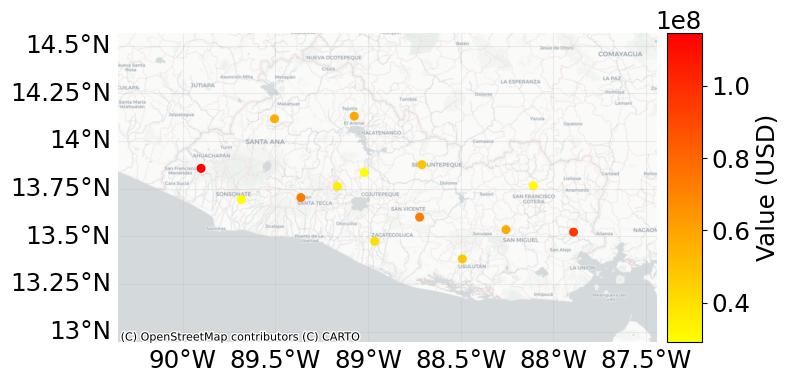

In [3]:
%matplotlib inline

# Plot the exposures
_ = entity.exposures.plot_basemap(
        ignore_zero=True,       # Whether to plot points with zero value
        buffer=50000,           # Add a buffer around the points to show a larger map region (measured in meters)
        s=30,                   # The size of point markers on the plot
        zoom=9,                 # The detail level of the map. 6 is good for a large country. 8 is good for a state or region. 13 for a city. 15 for a municipality.
        pop_name=False,         # Add the names of populated places to the map – often not necessary when you have a basemap
        vmax=None,              # Set the maximum value for the colour scale – use this if you want a consistent scheme across multiple plots.
        cmap="autumn_r",        # Colour scheme to use for the points. See https://matplotlib.org/stable/tutorials/colors/colormaps.html for options.
        figsize=(8, 10)         # Dimensions of the output figure
    )


#### Plot uncalibrated impact functions

We have a first-guess drought impact function in the Entity file:

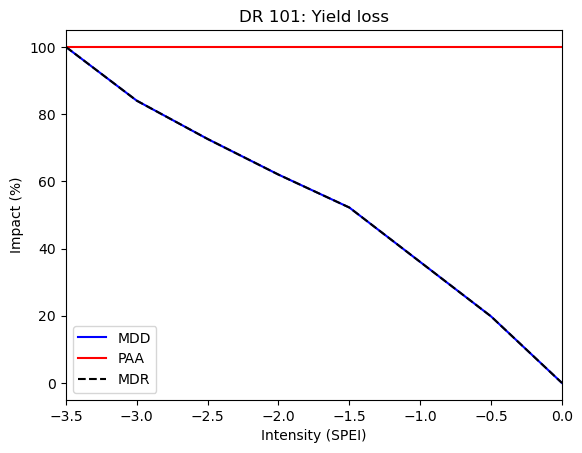

In [4]:
# Plot the impact function
_ = entity.impact_funcs.plot()

### Load Hazard data

As shown in the earlier notebook, we read the hazard information from a .tif file with a band for each year of simulated drought data.

We provide additional metadata to CLIMADA as we do this, including event frequency data.

In [5]:
import numpy as np
from climada.hazard import Hazard

start_year = 1972
end_year = 2023
n_years_data = end_year - start_year + 1

# Read in the hazard data
def read_hazard(haz_filepath, start_year, end_year):
    n_years_data = end_year - start_year + 1
    event_frequency = 1 / n_years_data

    haz = Hazard.from_raster(
        files_intensity = haz_filepath,
        band=list(np.arange(n_years_data) + 1),
        attrs={
            'unit': 'SPEI',   # as an index the SPEI has no units – so we can specify this or an empty string, as long as it is consistent with the Entity file Impact Functions
            'event_name': [str(year) for year in np.arange(start_year, end_year + 1)],     # We can optionally name the events
            'frequency': np.full(n_years_data, event_frequency)              # Define the frequency of each event
        },
        haz_type='DR',        # Specify that this is drought data
        window=None,          # Only read a window from the raster datasets, provided as a rasterio.windows.Windows object 
        geometry=None,        # Only read within a given geometry, provided as a list of shapely.geometry objects
    )

    # haz.intensity[haz.intensity > 0] = 0     # Set positive drought indices to zero to speed up calculation 
    return haz

haz = read_hazard(haz_filepath, start_year, end_year)

2026-06-11 15:41:30,974 - climada.util.coordinates - INFO - Reading ../data/hazard/annual/ElSalvador_SPEI12_present_maize.tif
2026-06-11 15:41:31,015 - climada.util.coordinates - INFO - Reading ../data/hazard/annual/ElSalvador_SPEI12_present_maize.tif


For plotting the most intense drought events, we again multiply the intensity by -1, so that stronger droughts have larger positive values, letting CLIMADA identify the largest positive values in to plot.

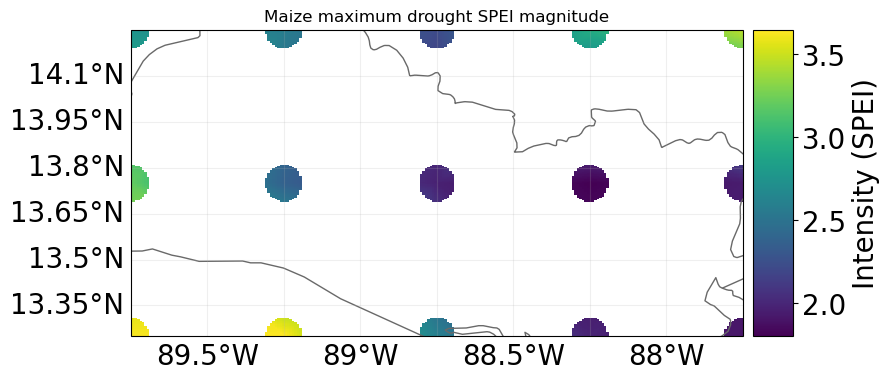

In [6]:
haz_inverted = copy.deepcopy(haz)
haz_inverted.intensity = -haz_inverted.intensity
axis = haz_inverted.plot_intensity(event=0)
_ = axis.set_title("Maize maximum drought SPEI magnitude")

In [7]:
# Assign centroids to match exposure points to the closest hazard centroid
entity.exposures.assign_centroids(hazard=haz, overwrite=True)

2026-06-11 15:41:32,772 - climada.entity.exposures.base - INFO - Matching 14 exposures with 15 centroids.
2026-06-11 15:41:32,797 - climada.util.coordinates - INFO - No exact centroid match found. Reprojecting coordinates to nearest neighbor closer than the threshold = 1.0 degree


### Load observations

As processed in previous notebooks.

In [8]:
import pandas as pd

obs = pd.read_csv(observations_filepath)

# Select and rename relevant columns
obs = obs[["Present-equivalent Production (kg)", "Present-equivalent Production anomaly (kg)", "Return Period (years)"]]
obs = obs.rename(columns={
    "Present-equivalent Production (kg)": "production",
    "Present-equivalent Production anomaly (kg)": "anomaly",
    "Return Period (years)": "rp"
})
obs["loss"] = -obs["anomaly"]

# Filter to drought events (events with a return period)
obs = obs[obs["rp"].notna()]
obs = obs.sort_values("rp", ascending=False)
obs = obs.set_index("rp")

display(obs)

,production,anomaly,loss
rp,,,
51.00,5.448996e+08,-3.180749e+08,3.180749e+08
25.50,7.033854e+08,-1.595892e+08,1.595892e+08
17.00,7.077518e+08,-1.552227e+08,1.552227e+08
12.75,7.137223e+08,-1.492522e+08,1.492522e+08
10.20,7.164952e+08,-1.464793e+08,1.464793e+08
8.50,7.370918e+08,-1.258828e+08,1.258828e+08
7.29,7.394049e+08,-1.235697e+08,1.235697e+08
6.38,7.493329e+08,-1.136417e+08,1.136417e+08
5.67,7.559794e+08,-1.069951e+08,1.069951e+08


## Write methods for reusable risk calculations

We calibrate the impact functions by running risk calculations, adjusting the impact functions, and attempting to reproduce the observations that we have.

In [9]:
import matplotlib.pyplot as plt
import contextily as ctx
from climada.entity import Exposures, ImpactFunc, ImpactFuncSet
from climada.engine import ImpactCalc, ImpactFreqCurve, Impact

# ----------------------------------------
# Methods for risk calculations
# ----------------------------------------

# Run a risk calculation and extract impact statistics at our chosen return periods
def risk_calc(entity, hazard, return_periods):
    entity.exposures.assign_centroids(hazard=hazard, overwrite=False)
    imp = ImpactCalc(entity.exposures, entity.impact_funcs, hazard).impact(save_mat=True, assign_centroids=False)
    rp_impacts = imp.calc_freq_curve(return_per=return_periods).impact
    return imp, pd.Series(rp_impacts, index=return_periods)

# Define a cost function that says how 'close' our modelled outputs are to the observations
# The automated calibration will use this to decide how well the model performs and will try to minimize its value
# Common options are
# - the (weighted) mean squared error between modelled and observed statistics
#     - with weights according to importance of different observations
#     - this prioritises getting large impacts correct
# - the (weighted) mean squared log error between modelled and observed statistics
#     - this priorises getting the order of magnitude of impacts correct
def cost_function(modelled, observed):
    assert np.all(modelled.index == observed.index), "Modelled and observed statistics must have the same index"
    cost = np.sqrt(((modelled - observed) ** 2).mean())
    return cost

# Swap a new impact function into an Entity file
def replace_impact_function(entity, new_impf):
    entity_new = copy.deepcopy(entity)    
    entity_new.impact_funcs = ImpactFuncSet([new_impf])
    return entity_new


# ----------------------------------------
# Methods for visualzation
# ----------------------------------------

def plot_observations_vs_modelled(observed: pd.Series, modelled: pd.Series, title: str=None):
    fig, axis = plt.subplots(figsize=(6, 3))
    sc = axis.scatter(observed, modelled, c=observed.index, cmap="copper", label="Observations")
    cbar = plt.colorbar(sc, ax=axis)
    cbar.set_label("Observation return period")
    axis.plot([observed.min(), observed.max()], [observed.min(), observed.max()], "k--", label="1:1 line")   # Add a 1:1 line for reference
    axis.set_xlabel("Observed")
    axis.set_ylabel("Modelled")
    if title is not None:
        axis.set_title(title)
    axis.legend(loc="upper left")
    plt.show()
    plt.close(axis.figure)


# Plot the exceedance curve
def plot_exceedance(imp: Impact, observed: pd.Series, title: str=None):
    exceedance_curve = imp.calc_freq_curve()
    fig, axis = plt.subplots(figsize=(6, 3))
    axis = exceedance_curve.plot(axis=axis, color="blue", label="Modelled exceedance curve")
    sc = axis.scatter(observed.index, observed.values, c=observed.index, cmap="copper", label="Observations")
    cbar = plt.colorbar(sc, ax=axis)
    cbar.set_label("Observation return period")

    axis.set_xlim(0, 60)
    if title is not None:
        axis.set_title(title)
    axis.legend(loc="upper left")
    plt.show()
    plt.close(axis.figure)


# Plot bar chart of losses for individual events (by category or region if desired)
# Specify 'split_exposure_by' to break down the losses by category or region. This should be a column in the exposures gdf, e.g. "category_id" or "region_id"
def plot_event_losses(imp: Impact, split_exposure_by: str=None, title: str=None):
    fig, axis = plt.subplots(figsize=(6, 3))
    if split_exposure_by is None:
        axis.bar(imp.event_name, imp.at_event)
    else:
        imp_at_reg = imp.impact_at_reg(agg_regions=entity.exposures.gdf[split_exposure_by])
        bottom = np.zeros(len(imp.at_event))
        for column in imp_at_reg.columns:
            p = axis.bar(imp.event_name, imp_at_reg[column], label=column, bottom=bottom)
            bottom += imp_at_reg[column]
        axis.legend(loc="upper left")
    axis.set_xlabel("Event Name")
    axis.set_ylabel(f"Impact ({imp.unit})")
    axis.tick_params(axis="x", rotation=45)
    # Only label every fifth year
    axis.set_xticks(axis.get_xticks()[::5])
    if title is not None:
        axis.set_title(title)
    plt.show()
    plt.close(axis.figure)


# Map expected annual impacts
def plot_map(imp: Impact, title: str=None):
    axis = imp.plot_basemap_eai_exposure(
        ignore_zero=False,
        buffer=50000,
        s=2,
        zoom=8,
        url=ctx.providers.CartoDB.Positron,
        cmap="autumn_r",
        figsize=(6, 10)
    )
    if title is not None:
        axis.set_title(title)
    plt.show()
    plt.close(axis.figure)


## Calibration

### First-guess analysis

We run an impact calculation with the first-guess impact function to get an idea of what we're working with

2026-06-11 15:41:32,936 - climada.entity.exposures.base - INFO - Exposures matching centroids already found for DR
2026-06-11 15:41:32,940 - climada.engine.impact_calc - INFO - Calculating impact for 14 assets (>0) and 52 events.
Log cost function value for uncalibrated model: 19.56


/var/folders/cs/l_5t6dbs03l7xx658mdw_t6w0000gn/T/ipykernel_81722/4279189843.py:14: DeprecationWarning: Calculating the frequency curve on user-specified return periods is deprecated. Use ImpactFreqCurve.calc_freq_curve().interpolate() instead.
  rp_impacts = imp.calc_freq_curve(return_per=return_periods).impact


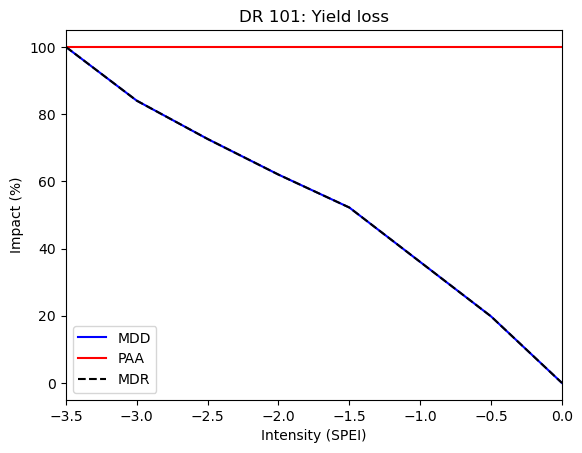

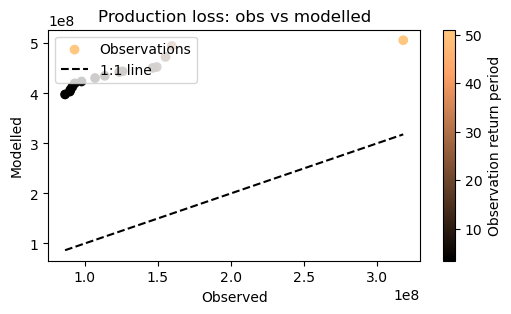

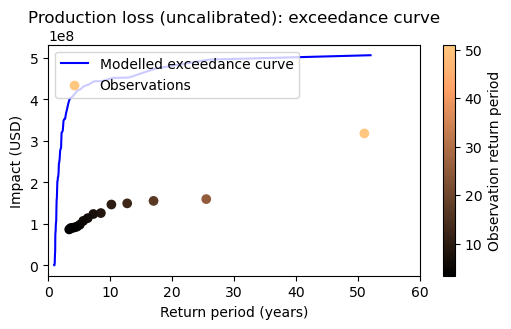

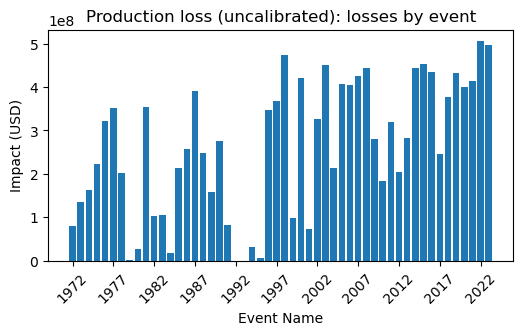

In [10]:
# Calculate risk
imp, modelled = risk_calc(entity, haz, return_periods=obs.index)
cost = cost_function(modelled, obs["loss"])
print(f"Log cost function value for uncalibrated model: {np.log(cost):.2f}")

# Create plots
entity.impact_funcs.plot()
title = f"Production loss: obs vs modelled"
plot_observations_vs_modelled(obs["loss"], modelled, title)
title = f"Production loss (uncalibrated): exceedance curve"
plot_exceedance(imp, obs["loss"], title)
title = f"Production loss (uncalibrated): losses by event"
plot_event_losses(imp, title=title)


### Discussion: first-guess analysis

The intial plots show us a few things that can guide the calibration:
- The first-guess impact function scales about linearly with drought intensity
- We significantly overestimate the impacts from all events

This means that we want to scale down the impact curve.



## Approach 1: simple scaling

Our first approach will be a simple scaling of the impact function. This will give us a sense of how well it performs.

The next blocks of code define a one-dimensional parameter search to optimize this value.

In [11]:
import logging

# This will be a simple grid search, where we loop through all combinations of parameters in a defined parameter space, run the risk calculation for each combination, and calculate the cost function for each combination. 
# We then identify the parameter combination that gives the lowest cost function value.

# First: define the parameter space that we'll be exploring
# Here we just scale along the y-axis (degree of damage)
parameter_space = {
    "y-scale": np.arange(0.1, 1.1, 0.05)
}

# Define a method to scale the impact function
def yscale_impact_function(impf, y_scale):
    impf_new = copy.deepcopy(impf)
    impf_new.mdd = impf_new.mdd * y_scale
    return impf_new

# Then, we loop through the parameter space, run the risk calculation, and calculate the cost function for each value.
# We store the results in a list.
def search_for_impf_yscale(
        entity: Entity,
        impf: ImpactFunc,
        y_scale_values: np.ndarray,
        obs: pd.Series):
    # Suppress logging from a couple of climada modules which can be verbose for many calculations in a loop
    logging.getLogger("climada.engine.impact_calc").setLevel(logging.WARNING)
    logging.getLogger("climada.entity.exposures.base").setLevel(logging.WARNING)

    results = []
    for y_scale in y_scale_values:
        print(f"Running risk calculation for y_scale={y_scale:.2f} ...")
            
        # Create a new impact function based on the original
        impf_new = yscale_impact_function(impf, y_scale)

        # Update the entity object with the new impact function
        entity_new = replace_impact_function(entity, impf_new)

        # Rerun the risk calculation and calculate the cost function as before
        _, modelled_stats = risk_calc(entity_new, haz, return_periods=obs.index)
        cost = cost_function(modelled_stats, obs)

        # Store the results
        results.append({
            "y_scale": y_scale,
            "cost": cost
        })

    logging.getLogger("climada.engine.impact_calc").setLevel(logging.INFO)
    logging.getLogger("climada.entity.exposures.base").setLevel(logging.INFO)
    return pd.DataFrame(results)


impf_original = entity.impact_funcs.get_func(haz_type='DR', fun_id=impf_id)

results_yscale_df = search_for_impf_yscale(
    entity=entity,
    impf=impf_original,
    y_scale_values=parameter_space["y-scale"],
    obs=obs["loss"]
)
display(results_yscale_df)

Running risk calculation for y_scale=0.10 ...
Running risk calculation for y_scale=0.15 ...
Running risk calculation for y_scale=0.20 ...
Running risk calculation for y_scale=0.25 ...
Running risk calculation for y_scale=0.30 ...
Running risk calculation for y_scale=0.35 ...
Running risk calculation for y_scale=0.40 ...
Running risk calculation for y_scale=0.45 ...
Running risk calculation for y_scale=0.50 ...
Running risk calculation for y_scale=0.55 ...
Running risk calculation for y_scale=0.60 ...
Running risk calculation for y_scale=0.65 ...
Running risk calculation for y_scale=0.70 ...
Running risk calculation for y_scale=0.75 ...
Running risk calculation for y_scale=0.80 ...
Running risk calculation for y_scale=0.85 ...
Running risk calculation for y_scale=0.90 ...
Running risk calculation for y_scale=0.95 ...
Running risk calculation for y_scale=1.00 ...
Running risk calculation for y_scale=1.05 ...


/var/folders/cs/l_5t6dbs03l7xx658mdw_t6w0000gn/T/ipykernel_81722/4279189843.py:14: DeprecationWarning: Calculating the frequency curve on user-specified return periods is deprecated. Use ImpactFreqCurve.calc_freq_curve().interpolate() instead.
  rp_impacts = imp.calc_freq_curve(return_per=return_periods).impact


,y_scale,cost
0,0.10,1.011751e+08
1,0.15,8.250599e+07
2,0.20,6.595205e+07
3,0.25,5.351366e+07
4,0.30,4.847017e+07
5,0.35,5.297742e+07
6,0.40,6.508043e+07
7,0.45,8.146117e+07
8,0.50,1.000399e+08
9,0.55,1.197984e+08


From this search we can identify the 'best' impact function and visualize the results:

In [12]:
# Get the index of the minimum value of 'cost'
def get_best_result(results_df):
    ix_best = results_df['cost'].idxmin()
    best_parameters = results_df.loc[ix_best, :]
    return dict(best_parameters)

best_yscale_parameters = get_best_result(results_yscale_df)
print(f"Best y-scaling value: {best_yscale_parameters['y_scale']:.2f}")
print(f"...with log cost: {np.log(best_yscale_parameters['cost']):.2f}")

Best y-scaling value: 0.30
...with log cost: 17.70


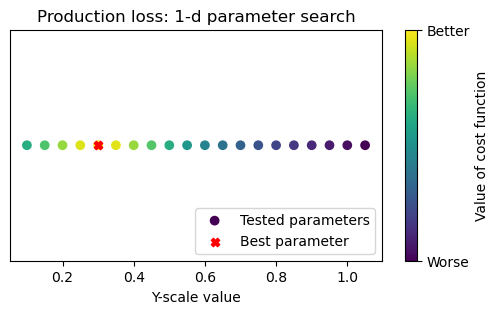

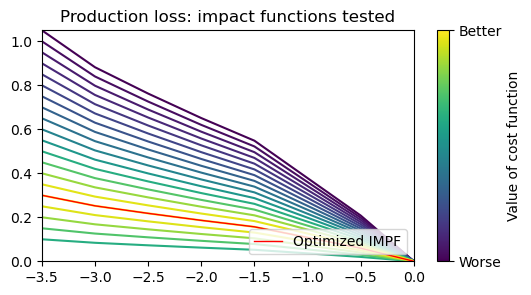

In [13]:
from matplotlib.colors import to_hex

# -------------------------------------------
# Methods to visualize the parameter search
# -------------------------------------------

# Helper function for assigning colours to scatter points
def assign_colour_to_costs(results_df):
    # Map the cost to a color according to viridis, where the best score (lowest) is yellow and the worst score (highest) is purple
    # we can do this by normalising the cost to be between 0 and 1, where 0 corresponds to the best 1 corresponds to the worst score
    # In addition, we take the logarithm of the cost to make the differences between smaller costs more visible
    costs = np.log10(results_df['cost'] + 1e-6)  # Add a small value to avoid taking log of zero
    max_score = costs.max()
    min_score = costs.min()
    norm_scores = 1 - (costs - min_score) / (max_score - min_score)
    results_df['colour'] = [to_hex(plt.cm.viridis(score)) for score in norm_scores]
    results_df = results_df.sort_values('cost', ascending=False)  # Also sort the dataframe by cost so that the best scores are plotted on top
    return results_df

# Plot the parameter search space, with points coloured according to the cost function value (yellow = good, purple = bad)
def plot_yscaling_search_space(results_df, title):
    results_df = assign_colour_to_costs(results_df)
    best_params = get_best_result(results_df)
    fig, axis = plt.subplots(figsize=(6, 3))
    axis.scatter(results_df['y_scale'], np.zeros_like(results_df['y_scale']), color=results_df['colour'], label='Tested parameters')
    axis.scatter(best_params['y_scale'], 0, color='red', label='Best parameter', marker='X')
    axis.legend(loc="lower right")

    axis.cbar = plt.colorbar(plt.cm.ScalarMappable(cmap='viridis'), ax=axis)
    axis.cbar.set_label('Value of cost function')
    axis.cbar.set_ticks([0, 1])
    axis.cbar.set_ticklabels(['Worse', 'Better'])
    
    axis.set_xlabel("Y-scale value")
    axis.set_yticks([])
    axis.set_title(title)
    plt.show()
    plt.close(axis.figure)

# Plot all the impact functions tested in the parameter search, coloured according to the cost function value
def plot_yscale_search_impfs(results_df, impf, title):
    results_df = assign_colour_to_costs(results_df)
    best_params = get_best_result(results_df)
    fig, axis = plt.subplots(figsize=(6, 3))
    for _, params in results_df.iterrows():
        impf_new = yscale_impact_function(impf, params['y_scale'])
        axis.plot(impf_new.intensity, impf_new.mdd, color=params['colour'])

    best_impf = yscale_impact_function(impf, best_params['y_scale'])
    axis.plot(best_impf.intensity, best_impf.mdd, color='red', linewidth=1, label='Optimized IMPF')
    axis.legend(loc="lower right")

    axis.set_xlim((best_impf.intensity.min(), best_impf.intensity.max()))
    axis.set_ylim((0, 1.05))

    axis.cbar = plt.colorbar(plt.cm.ScalarMappable(cmap='viridis'), ax=axis)
    axis.cbar.set_label('Value of cost function')
    axis.cbar.set_ticks([0, 1])
    axis.cbar.set_ticklabels(['Worse', 'Better'])

    axis.set_title(title)
    plt.show()
    plt.close(axis.figure)

plot_yscaling_search_space(results_yscale_df, "Production loss: 1-d parameter search")
plot_yscale_search_impfs(results_yscale_df, impf_original, "Production loss: impact functions tested")

### The optimized scaled impact function

(Note that we don't call this 'calibrated' – an automated search won't always choose the best function!)

2026-06-11 15:41:34,075 - climada.entity.exposures.base - INFO - Exposures matching centroids already found for DR
2026-06-11 15:41:34,079 - climada.engine.impact_calc - INFO - Calculating impact for 14 assets (>0) and 52 events.


/var/folders/cs/l_5t6dbs03l7xx658mdw_t6w0000gn/T/ipykernel_81722/4279189843.py:14: DeprecationWarning: Calculating the frequency curve on user-specified return periods is deprecated. Use ImpactFreqCurve.calc_freq_curve().interpolate() instead.
  rp_impacts = imp.calc_freq_curve(return_per=return_periods).impact


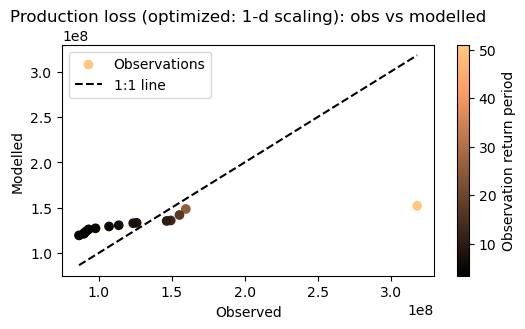

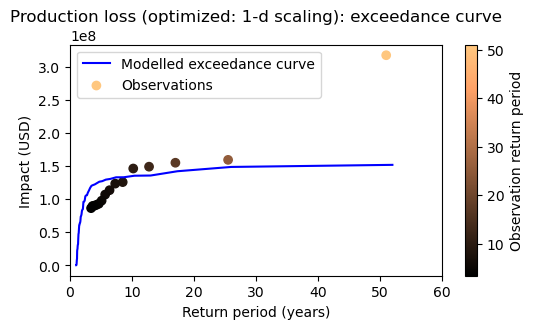

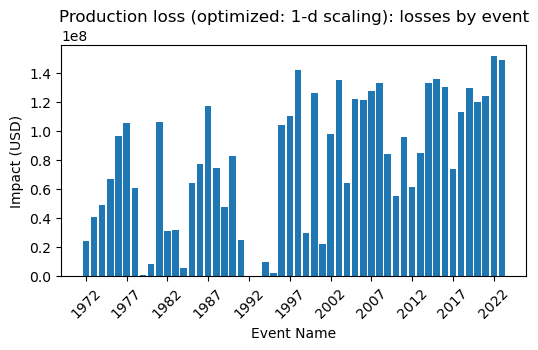

In [14]:
# Recreate the impact calculation with the best parameter values:
impf_optimized = yscale_impact_function(impf_original, best_yscale_parameters['y_scale'])

# Update the entity object with the new impact function
entity_optimized = replace_impact_function(entity, impf_optimized)

# Rerun the risk calculation and calculate the cost function as before
imp, modelled_stats = risk_calc(entity_optimized, haz, return_periods=obs.index)
cost = cost_function(modelled_stats, obs['loss'])

title = f"Production loss (optimized: 1-d scaling): obs vs modelled"
plot_observations_vs_modelled(obs["loss"], modelled_stats, title)
title = f"Production loss (optimized: 1-d scaling): exceedance curve"
plot_exceedance(imp, obs["loss"], title)
title = f"Production loss (optimized: 1-d scaling): losses by event"
plot_event_losses(imp, title=title)

### Discussion: simple scaling

The resulting impact function offers an improvement on the default but is still not very good.

From the plots above we see that:

- The most extreme impacts are not reproduced
- Impacts are too large at low return periods, and most years create impacts

This suggests that we need to decrease losses for weaker droughts, and increase them for stronger droughts.

## Approach 2: two-dimensional transformation

For the next step, we'll adjust the first-guess impact function by

- scaling along the x-axis: affects how steep the function is
- translating along the y-axis: affects the intensity at which impacts start

This will allow us more control over modelled losses.

Another option would be scaling along the x-axis. But since our impact function is roughly linear, it doesn't give us much that scaling on the y-axis hasn't already provided. 

In [15]:
# This will be another grid search, where we loop through all combinations of parameters in a defined parameter space.

parameter_space = {
    "x-translation": np.arange(-1.6, 0.3, 0.05),
    "y-scale": np.arange(0.1, 2.1, 0.05)
}

# Define a method to transform the impact function
def transform_impact_function_2d(impf, x_translate, y_scale):
    impf_new = copy.deepcopy(impf)
    impf_new.intensity = impf_new.intensity + x_translate
    impf_new.mdd = impf_new.mdd * y_scale
    impf_new.mdd = np.clip(impf_new.mdd, 0, 1)   # Ensure that the mdd values are between 0 and 1
    impf_new.intensity = np.clip(impf_new.intensity, -100, 0)  # Ensure that intensities stay below zero (this also keeps 0 intensity as 0 impact)
    return impf_new

# Then, we loop through the parameter space, run the risk calculation, and calculate the cost function for each value.
# We store the results in a list.
def search_for_impf_2d(
        entity: Entity,
        impf: ImpactFunc,
        x_translate_values: np.ndarray,
        y_scale_values: np.ndarray,
        obs: pd.Series):
    # Suppress logging from a couple of climada modules which can be verbose for many calculations in a loop
    logging.getLogger("climada.engine.impact_calc").setLevel(logging.WARNING)
    logging.getLogger("climada.entity.exposures.base").setLevel(logging.WARNING)

    results = []
    for x_translate in x_translate_values:
        print(f"Running risk calculation for x_translate={x_translate:.2f} and {len(y_scale_values)} y_scale values...")
        for y_scale in y_scale_values:
            # Create a new impact function based on the original
            impf_new = transform_impact_function_2d(impf, x_translate, y_scale)

            # Update the entity object with the new impact function
            entity_new = replace_impact_function(entity, impf_new)

            # Rerun the risk calculation and calculate the cost function as before
            _, modelled_stats = risk_calc(entity_new, haz, return_periods=obs.index)
            cost = cost_function(modelled_stats, obs)

            # Store the results
            results.append({
                "x_translate": x_translate,
                "y_scale": y_scale,
                "cost": cost
            })

    logging.getLogger("climada.engine.impact_calc").setLevel(logging.INFO)
    logging.getLogger("climada.entity.exposures.base").setLevel(logging.INFO)
    return pd.DataFrame(results)


results_2d_df = search_for_impf_2d(
    entity=entity,
    impf=impf_original,
    x_translate_values=parameter_space["x-translation"],
    y_scale_values=parameter_space["y-scale"],
    obs=obs["loss"]
)
display(results_2d_df)


Running risk calculation for x_translate=-1.60 and 40 y_scale values...
Running risk calculation for x_translate=-1.55 and 40 y_scale values...


/var/folders/cs/l_5t6dbs03l7xx658mdw_t6w0000gn/T/ipykernel_81722/4279189843.py:14: DeprecationWarning: Calculating the frequency curve on user-specified return periods is deprecated. Use ImpactFreqCurve.calc_freq_curve().interpolate() instead.
  rp_impacts = imp.calc_freq_curve(return_per=return_periods).impact


Running risk calculation for x_translate=-1.50 and 40 y_scale values...
Running risk calculation for x_translate=-1.45 and 40 y_scale values...
Running risk calculation for x_translate=-1.40 and 40 y_scale values...
Running risk calculation for x_translate=-1.35 and 40 y_scale values...
Running risk calculation for x_translate=-1.30 and 40 y_scale values...
Running risk calculation for x_translate=-1.25 and 40 y_scale values...
Running risk calculation for x_translate=-1.20 and 40 y_scale values...
Running risk calculation for x_translate=-1.15 and 40 y_scale values...
Running risk calculation for x_translate=-1.10 and 40 y_scale values...
Running risk calculation for x_translate=-1.05 and 40 y_scale values...
Running risk calculation for x_translate=-1.00 and 40 y_scale values...
Running risk calculation for x_translate=-0.95 and 40 y_scale values...
Running risk calculation for x_translate=-0.90 and 40 y_scale values...
Running risk calculation for x_translate=-0.85 and 40 y_scale va

,x_translate,y_scale,cost
0,-1.60,0.10,1.339232e+08
1,-1.60,0.15,1.301706e+08
2,-1.60,0.20,1.264279e+08
3,-1.60,0.25,1.226962e+08
4,-1.60,0.30,1.189764e+08
...,...,...,...
1515,0.25,1.85,6.420850e+08
1516,0.25,1.90,6.490337e+08
1517,0.25,1.95,6.518267e+08
1518,0.25,2.00,6.523693e+08


In [16]:
best_2d_parameters = get_best_result(results_2d_df)
print(f"Best x_translate value: {best_2d_parameters['x_translate']:.2f}")
print(f"Best y_scale value: {best_2d_parameters['y_scale']:.2f}")
print(f"...with log cost: {np.log(best_2d_parameters['cost']):.2f}")

Best x_translate value: -1.30
Best y_scale value: 1.00
...with log cost: 17.16


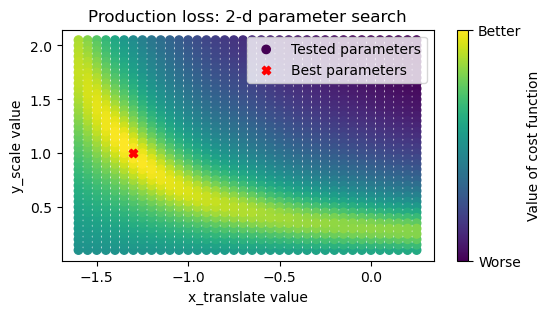

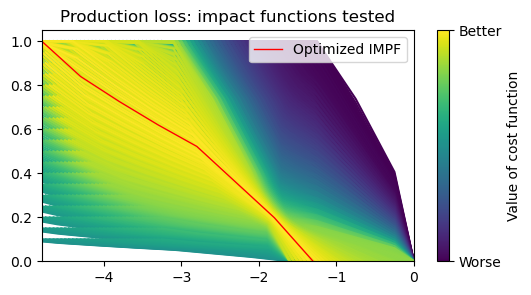

In [17]:
# -------------------------------------------
# Methods to visualize the 2-d parameter search
# -------------------------------------------

# Plot the parameter search space, with points coloured according to the cost function value (yellow = good, purple = bad)
def plot_2d_search_space(results_df, title):
    results_df = assign_colour_to_costs(results_df)
    best_params = get_best_result(results_df)
    param_names = list(best_params.keys())
    fig, axis = plt.subplots(figsize=(6, 3))
    axis.scatter(results_df[param_names[0]], results_df[param_names[1]], color=results_df['colour'], label='Tested parameters')
    axis.scatter(best_params[param_names[0]], best_params[param_names[1]], color='red', label='Best parameters', marker='X')
    axis.legend(loc="upper right")

    axis.cbar = plt.colorbar(plt.cm.ScalarMappable(cmap='viridis'), ax=axis)
    axis.cbar.set_label('Value of cost function')
    axis.cbar.set_ticks([0, 1])
    axis.cbar.set_ticklabels(['Worse', 'Better'])
    
    axis.set_xlabel(f"{param_names[0]} value")
    axis.set_ylabel(f"{param_names[1]} value")
    axis.set_title(title)
    plt.show()
    plt.close(axis.figure)

# Plot all the impact functions tested in the parameter search, coloured according to the cost function value
def plot_2d_search_impfs(results_df, impf, title):
    results_df = assign_colour_to_costs(results_df)
    best_params = get_best_result(results_df)
    param_names = list(best_params.keys())

    fig, axis = plt.subplots(figsize=(6, 3))
    for _, params in results_df.iterrows():
        impf_new = transform_impact_function_2d(impf, params[param_names[0]], params[param_names[1]])
        axis.plot(impf_new.intensity, impf_new.mdd, color=params['colour'])

    best_impf = transform_impact_function_2d(impf, best_params[param_names[0]], best_params[param_names[1]])
    axis.plot(best_impf.intensity, best_impf.mdd, color='red', linewidth=1, label='Optimized IMPF')
    axis.legend(loc="upper right")

    axis.set_xlim((best_impf.intensity.min(), 0))
    axis.set_ylim((0, 1.05))

    axis.cbar = plt.colorbar(plt.cm.ScalarMappable(cmap='viridis'), ax=axis)
    axis.cbar.set_label('Value of cost function')
    axis.cbar.set_ticks([0, 1])
    axis.cbar.set_ticklabels(['Worse', 'Better'])

    axis.set_title(title)
    plt.show()
    plt.close(axis.figure)

plot_2d_search_space(results_2d_df, "Production loss: 2-d parameter search")
plot_2d_search_impfs(results_2d_df, impf_original, "Production loss: impact functions tested")

### The optimized transformed impact function

2026-06-11 15:41:41,703 - climada.entity.exposures.base - INFO - Exposures matching centroids already found for DR
2026-06-11 15:41:41,707 - climada.engine.impact_calc - INFO - Calculating impact for 14 assets (>0) and 52 events.


/var/folders/cs/l_5t6dbs03l7xx658mdw_t6w0000gn/T/ipykernel_81722/4279189843.py:14: DeprecationWarning: Calculating the frequency curve on user-specified return periods is deprecated. Use ImpactFreqCurve.calc_freq_curve().interpolate() instead.
  rp_impacts = imp.calc_freq_curve(return_per=return_periods).impact


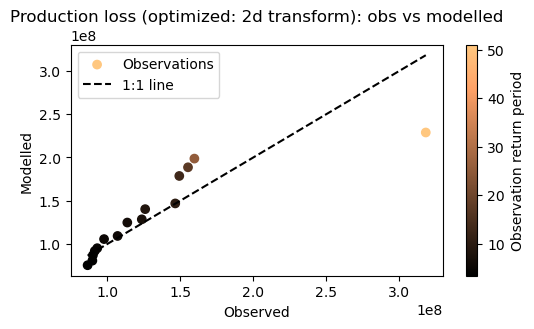

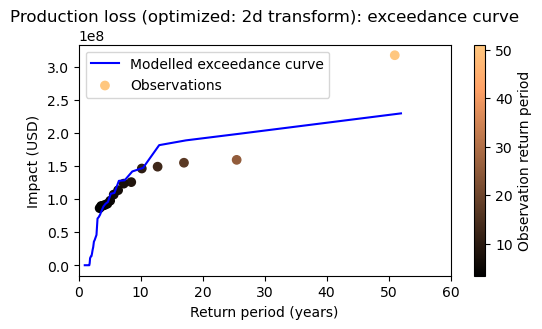

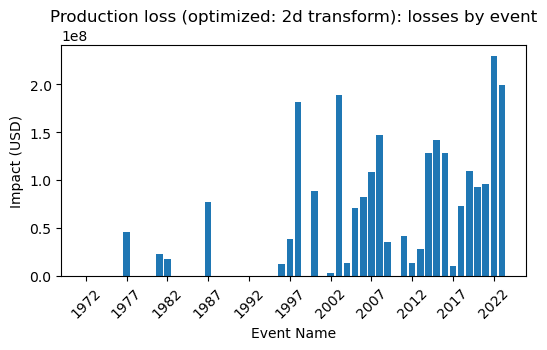

In [18]:
# Recreate the impact calculation with the best parameter values:
impf_best_2d = transform_impact_function_2d(impf_original, best_2d_parameters['x_translate'], best_2d_parameters['y_scale'])

# Update the entity object with the new impact function
entity_optimized = replace_impact_function(entity, impf_best_2d)

# Rerun the risk calculation and calculate the cost function as before
imp, modelled_stats = risk_calc(entity_optimized, haz, return_periods=obs.index)
cost = cost_function(modelled_stats, obs['loss'])

title = f"Production loss (optimized: 2d transform): obs vs modelled"
plot_observations_vs_modelled(obs["loss"], modelled_stats, title=title)
title = f"Production loss (optimized: 2d transform): exceedance curve"
plot_exceedance(imp, obs["loss"], title=title)
title = f"Production loss (optimized: 2d transform): losses by event"
plot_event_losses(imp, title=title)

### Discussion: 2-d transform parameter search

The new optimized impact function performs a lot better, but still has limitations.

- The lower return period observations are reproduced very well.
- However at return periods above about 10 years the fit breaks down. Between 10 and 30 years the model overestimates, and the highest intensity drought is underestimated

This is a difficult fit. The plotted space of impact functions shows us that there is a wide range of parameters that give a 'good' fit (shaded yellow), and when they are plotted there is big variety amongst them, except at an SPEI12 of about -2.

In addition, we see that the simulated drought timeline shows increasing drought frequency and intensity over time (remember this is a model simulation of 1972-2023, not historical hazard). The fact that there is a non-stationary baseline to this climate makes the fit even more challenging.

One valid option to improve the modelling would be to exclude years before 1994: this would leave 30 years, which is the usual window of time to represent a single 'climate', and would remove background climate change. However with such a short simulation duration, we can't reproduce higher return period observations: we would need to add additional SPEI climate simulations for the 1994-2023 period.


## Approach 3: sigmoid function

When calibrating, it is worth avoiding adding too many parameters to tune on, especially when you have a limited number of observations. This risks overfitting the model.

So rather than adding additional parameters, we will look at other functional forms.

A sigmoid function is a reliable guess in most risk modelling situations. Here it seems suitable because it allows us to specify an impact function that increases slowly at first and then increases.

CLIMADA's `ImpactFunc.from_sigmoid_impf` allows you to create a sigmoid impact function using three parameters. We'll use that here, meaning we are searching a three-dimensional parameter space.

We start by visualizing an example curve, and then explore a full parameter space.

<Axes: title={'center': 'DR 101: '}, xlabel='Intensity ()', ylabel='Impact (%)'>

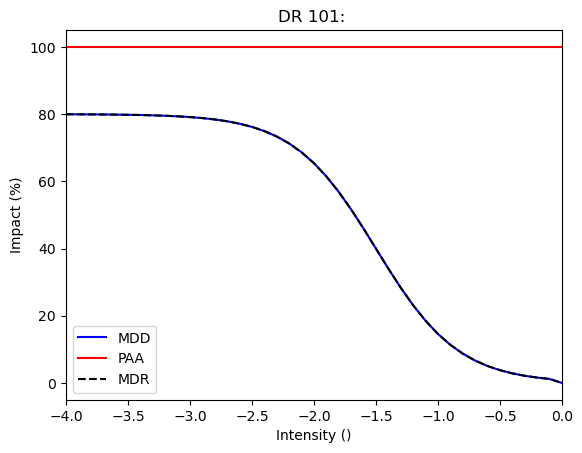

In [19]:
def create_sigmoid_impf(k, x0, L):
    impf_new = ImpactFunc.from_sigmoid_impf(intensity=(-4, 0.1, 0.1), L=L, k=k, x0=x0, impf_id=impf_id, haz_type='DR')
    impf_new.mdd = np.clip(impf_new.mdd, 0, 1)                  # Ensure that the mdd values are between 0 and 1
    impf_new.intensity = np.clip(impf_new.intensity, -100, 0)   # Ensure that intensities stay below zero (this also keeps 0 intensity as 0 impact)
    impf_new.mdd[-1] = 0                                        # Ensure that 0 hazard corresponds to 0 impact
    return impf_new

example_impf = create_sigmoid_impf(k=-3, x0=-1.5, L=0.8)
example_impf.plot()

Running risk calculation for k=-8.00 and 40 x0 values...


/var/folders/cs/l_5t6dbs03l7xx658mdw_t6w0000gn/T/ipykernel_81722/4279189843.py:14: DeprecationWarning: Calculating the frequency curve on user-specified return periods is deprecated. Use ImpactFreqCurve.calc_freq_curve().interpolate() instead.
  rp_impacts = imp.calc_freq_curve(return_per=return_periods).impact


Running risk calculation for k=-7.90 and 40 x0 values...
Running risk calculation for k=-7.80 and 40 x0 values...
Running risk calculation for k=-7.70 and 40 x0 values...
Running risk calculation for k=-7.60 and 40 x0 values...
Running risk calculation for k=-7.50 and 40 x0 values...
Running risk calculation for k=-7.40 and 40 x0 values...
Running risk calculation for k=-7.30 and 40 x0 values...
Running risk calculation for k=-7.20 and 40 x0 values...
Running risk calculation for k=-7.10 and 40 x0 values...
Running risk calculation for k=-7.00 and 40 x0 values...
Running risk calculation for k=-6.90 and 40 x0 values...
Running risk calculation for k=-6.80 and 40 x0 values...
Running risk calculation for k=-6.70 and 40 x0 values...
Running risk calculation for k=-6.60 and 40 x0 values...
Running risk calculation for k=-6.50 and 40 x0 values...
Running risk calculation for k=-6.40 and 40 x0 values...
Running risk calculation for k=-6.30 and 40 x0 values...
Running risk calculation for k=

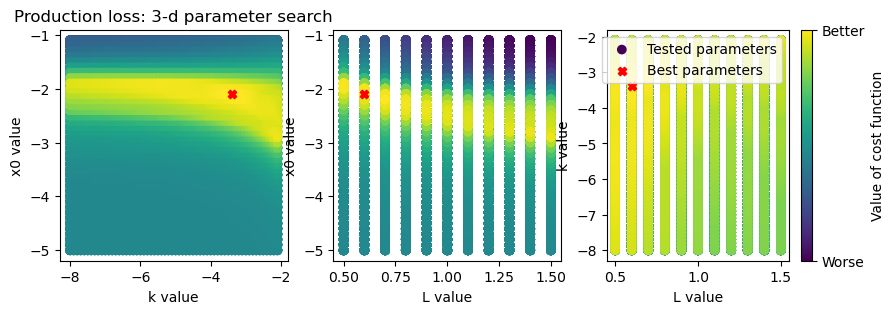

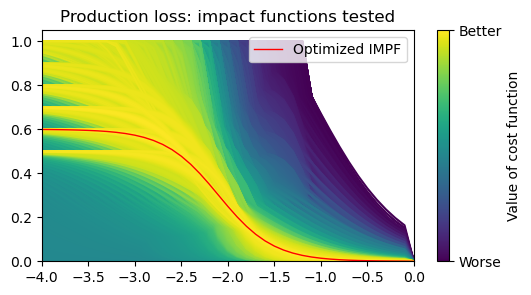

In [20]:
parameter_space = {
    "k": np.arange(-8, -2, 0.1),    # maximum steepness of the curve
    "x0": np.arange(-5, -1, 0.1),    # midpoint of the curve
    "L": np.arange(0.5, 1.55, 0.1)  # maximum value of the curve
}


def search_for_sigmoid(
        entity: Entity,
        k_values: np.ndarray,
        x0_values: np.ndarray,
        L_values: np.ndarray,
        obs: pd.Series
    ):
    # Suppress logging from a couple of climada modules which can be verbose for many calculations in a loop
    logging.getLogger("climada.engine.impact_calc").setLevel(logging.WARNING)
    logging.getLogger("climada.entity.exposures.base").setLevel(logging.WARNING)

    results = []
    for k in k_values:
        print(f"Running risk calculation for k={k:.2f} and {len(x0_values)} x0 values...")
        for x0 in x0_values:
            for L in L_values:
                # Create a new impact function based on the original
                impf_new = create_sigmoid_impf(k, x0, L)

                # Update the entity object with the new impact function
                entity_new = replace_impact_function(entity, impf_new)

                # Rerun the risk calculation and calculate the cost function as before
                _, modelled_stats = risk_calc(entity_new, haz, return_periods=obs.index)
                cost = cost_function(modelled_stats, obs)

                # Store the results
                results.append({
                    "k": k,
                    "x0": x0,
                    "L": L,
                    "cost": cost
                })

    logging.getLogger("climada.engine.impact_calc").setLevel(logging.INFO)
    logging.getLogger("climada.entity.exposures.base").setLevel(logging.INFO)
    return pd.DataFrame(results)

# Plotting the search space creates three subplots, each showing a two-dimensional slice of the 3-d parameter space, 
# with points coloured according to the best cost function value (yellow = good, purple = bad)
def plot_3d_search_space(results_df, title):
    results_df = assign_colour_to_costs(results_df)
    best_params = get_best_result(results_df)
    param_names = list(best_params.keys())
    fig, axis = plt.subplots(1, 3, figsize=(10, 3))
    axis[0].scatter(results_df[param_names[0]], results_df[param_names[1]], color=results_df['colour'], label='Tested parameters')
    axis[0].scatter(best_params[param_names[0]], best_params[param_names[1]], color='red', label='Best parameters', marker='X')
    axis[1].scatter(results_df[param_names[2]], results_df[param_names[1]], color=results_df['colour'], label='Tested parameters')
    axis[1].scatter(best_params[param_names[2]], best_params[param_names[1]], color='red', label='Best parameters', marker='X')
    axis[2].scatter(results_df[param_names[2]], results_df[param_names[0]], color=results_df['colour'], label='Tested parameters')
    axis[2].scatter(best_params[param_names[2]], best_params[param_names[0]], color='red', label='Best parameters', marker='X')

    axis[0].set_xlabel(f"{param_names[0]} value")
    axis[0].set_ylabel(f"{param_names[1]} value")
    axis[1].set_xlabel(f"{param_names[2]} value")
    axis[1].set_ylabel(f"{param_names[1]} value")
    axis[2].set_xlabel(f"{param_names[2]} value")
    axis[2].set_ylabel(f"{param_names[0]} value")

    axis[2].legend(loc="upper right")

    axis[2].cbar = plt.colorbar(plt.cm.ScalarMappable(cmap='viridis'), ax=axis[2])
    axis[2].cbar.set_label('Value of cost function')
    axis[2].cbar.set_ticks([0, 1])
    axis[2].cbar.set_ticklabels(['Worse', 'Better'])
    
    axis[0].set_title(title)
    plt.show()
    plt.close(axis[0].figure)


# Plot all the impact functions tested in the parameter search, coloured according to the cost function value
def plot_sigmoid_search_impfs(results_df, title):
    results_df = assign_colour_to_costs(results_df)
    best_params = get_best_result(results_df)
    param_names = list(best_params.keys())

    fig, axis = plt.subplots(figsize=(6, 3))
    for _, params in results_df.iterrows():
        impf_new = create_sigmoid_impf(params["k"], params["x0"], params["L"])
        axis.plot(impf_new.intensity, impf_new.mdd, color=params['colour'])

    best_impf = create_sigmoid_impf(best_params["k"], best_params["x0"], best_params["L"])
    axis.plot(best_impf.intensity, best_impf.mdd, color='red', linewidth=1, label='Optimized IMPF')
    axis.legend(loc="upper right")

    axis.set_xlim((best_impf.intensity.min(), 0))
    axis.set_ylim((0, 1.05))

    axis.cbar = plt.colorbar(plt.cm.ScalarMappable(cmap='viridis'), ax=axis)
    axis.cbar.set_label('Value of cost function')
    axis.cbar.set_ticks([0, 1])
    axis.cbar.set_ticklabels(['Worse', 'Better'])

    axis.set_title(title)
    plt.show()
    plt.close(axis.figure)


# Run the search and visualise the results
results_sigmoid_df = search_for_sigmoid(
    entity=entity,
    k_values=parameter_space["k"],
    x0_values=parameter_space["x0"],
    L_values=parameter_space["L"],
    obs=obs["loss"]
)

best_sigmoid_parameters = get_best_result(results_sigmoid_df)
print(f"Best k value: {best_sigmoid_parameters['k']:.2f}")
print(f"Best x0 value: {best_sigmoid_parameters['x0']:.2f}")
print(f"Best L value: {best_sigmoid_parameters['L']:.2f}")
print(f"...with log cost: {np.log(best_sigmoid_parameters['cost']):.2f}")

plot_3d_search_space(results_sigmoid_df, "Production loss: 3-d parameter search")
plot_sigmoid_search_impfs(results_sigmoid_df, "Production loss: impact functions tested")

### The optimized sigmoid function

2026-06-11 15:43:48,914 - climada.entity.exposures.base - INFO - Exposures matching centroids already found for DR
2026-06-11 15:43:48,929 - climada.engine.impact_calc - INFO - Calculating impact for 14 assets (>0) and 52 events.
2026-06-11 15:43:48,931 - climada.hazard.base - WARNING - Impact function id=101 has mdr(0) != 0.The mean damage ratio must thus be computed for all values ofhazard intensity including 0 which can be very time consuming.


/var/folders/cs/l_5t6dbs03l7xx658mdw_t6w0000gn/T/ipykernel_81722/4279189843.py:14: DeprecationWarning: Calculating the frequency curve on user-specified return periods is deprecated. Use ImpactFreqCurve.calc_freq_curve().interpolate() instead.
  rp_impacts = imp.calc_freq_curve(return_per=return_periods).impact


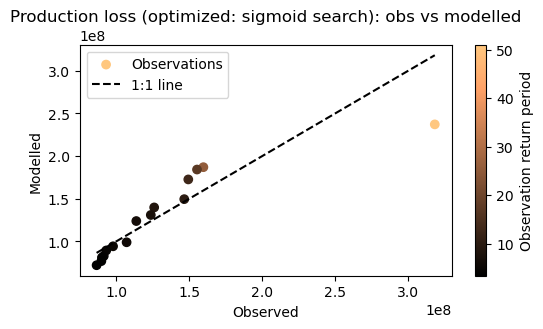

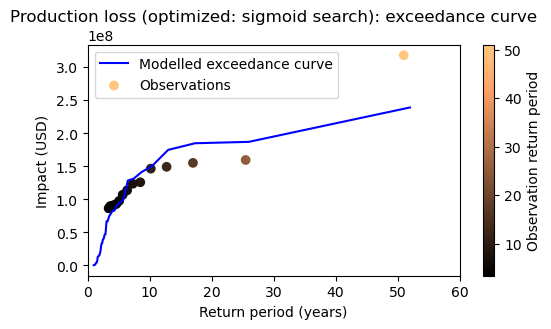

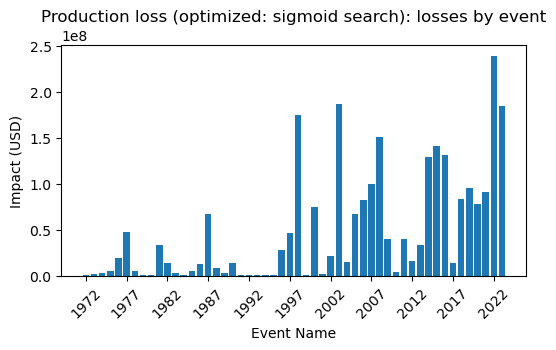

In [21]:
# Recreate the impact calculation with the best parameter values:
impf_best_sigmoid = ImpactFunc.from_sigmoid_impf(intensity=(-4, 0.1, 0.1), L=best_sigmoid_parameters['L'], k=best_sigmoid_parameters['k'], x0=best_sigmoid_parameters['x0'], impf_id=impf_id, haz_type='DR')

# Update the entity object with the new impact function
entity_optimized = replace_impact_function(entity, impf_best_sigmoid)

# Rerun the risk calculation and calculate the cost function as before
imp, modelled_stats = risk_calc(entity_optimized, haz, return_periods=obs.index)
cost = cost_function(modelled_stats, obs['loss'])

title = f"Production loss (optimized: sigmoid search): obs vs modelled"
plot_observations_vs_modelled(obs["loss"], modelled_stats, title=title)
title = f"Production loss (optimized: sigmoid search): exceedance curve"
plot_exceedance(imp, obs["loss"], title=title)
title = f"Production loss (optimized: sigmoid search): losses by event"
plot_event_losses(imp, title=title)

### Discussion: sigmoid function

This is again an improvement. We are still overestimating return period impacts between 10 and 30 years, and underestimating the 50-year return period, but less so.

It's becoming clear this is a challenge, because the first and second-most severe drought years are fairly similar in terms of hazard values, and we haven't found a functional form that distinguishes well between them.

Looking again at the plot of all functions explored, we see that there is good agreement at intensities above -2, but considerable uncertainty below that. This is likely because there are very few events with such severe drought intensities affecting exposures, meaning the function is less constrained below -2. The hazard plot at the start of this notebook suggests that this is the case.



## Approach 4: capped quadratic curve

Another functional form that showed promise in testing was a 'capped quadratic curve'. A quadratic curve, chosen and modified such that

- its minumum value is zero
- at intensities higher (droughts weaker) than the minimum point (`impact_start_thresh`), impacts are set to zero
- the user sets a drought intensity (`impact_max_thresh`) at which the highest impacts (`max_impact`) are reached values are capped beyond this.

Again, this is defined through three parameters, and we will search a space for a suitable function.

We start by plotting an example curve, then searching the parameter space.

Note: remember that when an impact function is used to calculate an impact outside of the range it is defined on, the impacts for the nearest defined point are used. That is, it is extrapolated as a constant. This is important to bear in mind while reading charts in the following sections.


<Axes: title={'center': 'DR 101: Yield loss'}, xlabel='Intensity (SPEI)', ylabel='Impact (%)'>

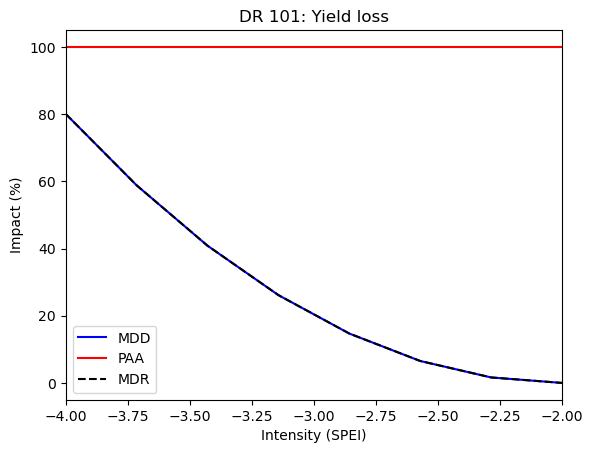

In [22]:
def make_quadratic_impact_function(
        original_impf: ImpactFunc,
        impact_start_thresh: float,
        impact_max_thresh: float,
        max_impact: float
    ):
    if impact_start_thresh >= 0 and impact_start_thresh <= 1e-6:
        impact_start_thresh = 0  # Weird we have to fix this
    impf = copy.deepcopy(original_impf)
    impf.intensity = np.linspace(impact_max_thresh, impact_start_thresh, len(impf.intensity))
    mu = max_impact / (impact_max_thresh - impact_start_thresh) ** 2
    impf.mdd = mu * (impf.intensity - impact_start_thresh) ** 2
    assert impf.calc_mdr(0) == 0, "Impact function does not give zero impact at zero hazard"
    assert impf.calc_mdr(impact_start_thresh) == 0, "Impact function does not give zero impact at impact_start_thresh"
    assert np.abs(impf.calc_mdr(impact_max_thresh) - max_impact) < 1e-6, "Impact function does not give max_impact at impact_max_thresh"
    return impf

impf_example = make_quadratic_impact_function(impf_original, impact_start_thresh=-2, impact_max_thresh=-4, max_impact=0.8)
impf_example.plot()

Running risk calculation for impact_start_thresh=-2.00 and 40 impact_max_thresh * 13 max_impact values...


/var/folders/cs/l_5t6dbs03l7xx658mdw_t6w0000gn/T/ipykernel_81722/4279189843.py:14: DeprecationWarning: Calculating the frequency curve on user-specified return periods is deprecated. Use ImpactFreqCurve.calc_freq_curve().interpolate() instead.
  rp_impacts = imp.calc_freq_curve(return_per=return_periods).impact


Running risk calculation for impact_start_thresh=-1.90 and 40 impact_max_thresh * 13 max_impact values...
Running risk calculation for impact_start_thresh=-1.80 and 40 impact_max_thresh * 13 max_impact values...
Running risk calculation for impact_start_thresh=-1.70 and 40 impact_max_thresh * 13 max_impact values...
Running risk calculation for impact_start_thresh=-1.60 and 40 impact_max_thresh * 13 max_impact values...
Running risk calculation for impact_start_thresh=-1.50 and 40 impact_max_thresh * 13 max_impact values...
Running risk calculation for impact_start_thresh=-1.40 and 40 impact_max_thresh * 13 max_impact values...
Running risk calculation for impact_start_thresh=-1.30 and 40 impact_max_thresh * 13 max_impact values...
Running risk calculation for impact_start_thresh=-1.20 and 40 impact_max_thresh * 13 max_impact values...
Running risk calculation for impact_start_thresh=-1.10 and 40 impact_max_thresh * 13 max_impact values...
Running risk calculation for impact_start_thre

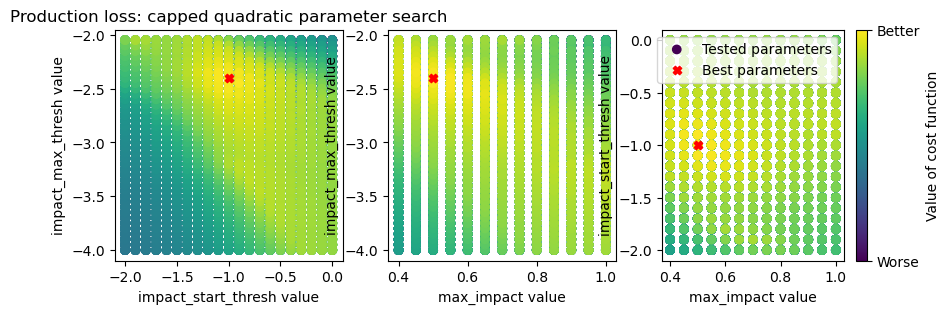

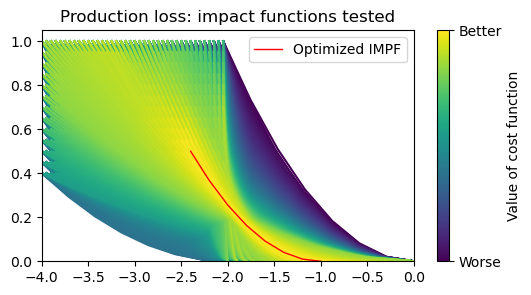

In [23]:
parameter_space = {
    "impact_start_thresh": np.arange(-2, 0.05, 0.1),  # SPEI at which drought impacts start
    "impact_max_thresh": np.arange(-4, -2, 0.05),      # SPEI at which drought impacts reach their maximum
    "max_impact": np.arange(0.4, 1.05, 0.05)    # maximum possible fractional loss
}

def search_for_capped_quadratic(
        entity: Entity,
        original_impf: ImpactFunc,
        impact_start_thresh_values: np.ndarray,
        impact_max_thresh_values: np.ndarray,
        max_impact_values: np.ndarray,
        obs: pd.Series
    ):
    # Suppress logging from a couple of climada modules which can be verbose for many calculations in a loop
    logging.getLogger("climada.engine.impact_calc").setLevel(logging.WARNING)
    logging.getLogger("climada.entity.exposures.base").setLevel(logging.WARNING)

    results = []
    for x in impact_start_thresh_values:
        print(f"Running risk calculation for impact_start_thresh={x:.2f} and {len(impact_max_thresh_values)} impact_max_thresh * {len(max_impact_values)} max_impact values...")
        for y in impact_max_thresh_values:
            if y >= x:   # Ensure that the max impact threshold is less than the impact start threshold
                continue
            for z in max_impact_values:
                # Create a new impact function based on the original
                impf_new = make_quadratic_impact_function(original_impf, x, y, z)

                # Update the entity object with the new impact function
                entity_new = replace_impact_function(entity, impf_new)

                # Rerun the risk calculation and calculate the cost function as before
                _, modelled_stats = risk_calc(entity_new, haz, return_periods=obs.index)
                cost = cost_function(modelled_stats, obs)

                # Store the results
                results.append({
                    "impact_start_thresh": x,
                    "impact_max_thresh": y,
                    "max_impact": z,
                    "cost": cost
                })

    logging.getLogger("climada.engine.impact_calc").setLevel(logging.INFO)
    logging.getLogger("climada.entity.exposures.base").setLevel(logging.INFO)
    return pd.DataFrame(results)

def plot_3d_search_impfs(results_df, original_impf, title, x_min=-4):
    results_df = assign_colour_to_costs(results_df)
    best_params = get_best_result(results_df)
    param_names = list(best_params.keys())

    fig, axis = plt.subplots(figsize=(6, 3))
    for _, params in results_df.iterrows():
        impf_new = make_quadratic_impact_function(original_impf, params[param_names[0]], params[param_names[1]], params[param_names[2]])
        axis.plot(impf_new.intensity, impf_new.mdd, color=params['colour'])

    best_impf = make_quadratic_impact_function(original_impf, best_params[param_names[0]], best_params[param_names[1]], best_params[param_names[2]])
    axis.plot(best_impf.intensity, best_impf.mdd, color='red', linewidth=1, label='Optimized IMPF')
    axis.legend(loc="upper right")

    axis.set_xlim((x_min, 0))
    axis.set_ylim((0, 1.05))

    axis.cbar = plt.colorbar(plt.cm.ScalarMappable(cmap='viridis'), ax=axis)
    axis.cbar.set_label('Value of cost function')
    axis.cbar.set_ticks([0, 1])
    axis.cbar.set_ticklabels(['Worse', 'Better'])

    axis.set_title(title)
    plt.show()
    plt.close(axis.figure)


results_quadratic_df = search_for_capped_quadratic(
    entity=entity,
    original_impf=impf_original,
    impact_start_thresh_values=parameter_space["impact_start_thresh"],
    impact_max_thresh_values=parameter_space["impact_max_thresh"],
    max_impact_values=parameter_space["max_impact"],
    obs=obs["loss"]
)

best_quadratic_parameters = get_best_result(results_quadratic_df)
print(f"Best impact_start_thresh value: {best_quadratic_parameters['impact_start_thresh']:.2f}")
print(f"Best impact_max_thresh value: {best_quadratic_parameters['impact_max_thresh']:.2f}")
print(f"Best max_impact value: {best_quadratic_parameters['max_impact']:.2f}")
print(f"...with log cost: {np.log(best_quadratic_parameters['cost']):.2f}")

plot_3d_search_space(results_quadratic_df, "Production loss: capped quadratic parameter search")
plot_3d_search_impfs(results_quadratic_df, impf_original, "Production loss: impact functions tested", x_min=-4)

### The optimized capped quadratic impact function

2026-06-11 15:44:45,901 - climada.entity.exposures.base - INFO - Exposures matching centroids already found for DR
2026-06-11 15:44:45,909 - climada.engine.impact_calc - INFO - Calculating impact for 14 assets (>0) and 52 events.


/var/folders/cs/l_5t6dbs03l7xx658mdw_t6w0000gn/T/ipykernel_81722/4279189843.py:14: DeprecationWarning: Calculating the frequency curve on user-specified return periods is deprecated. Use ImpactFreqCurve.calc_freq_curve().interpolate() instead.
  rp_impacts = imp.calc_freq_curve(return_per=return_periods).impact


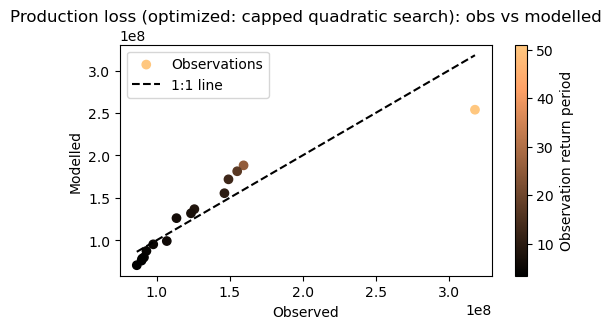

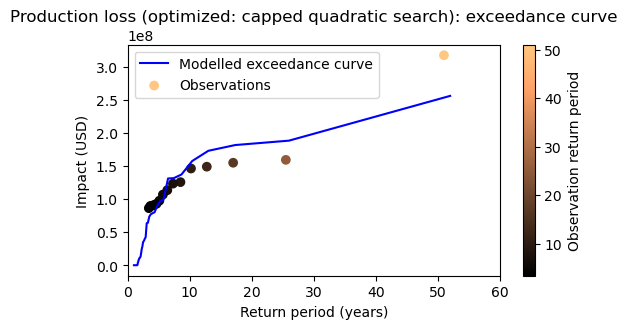

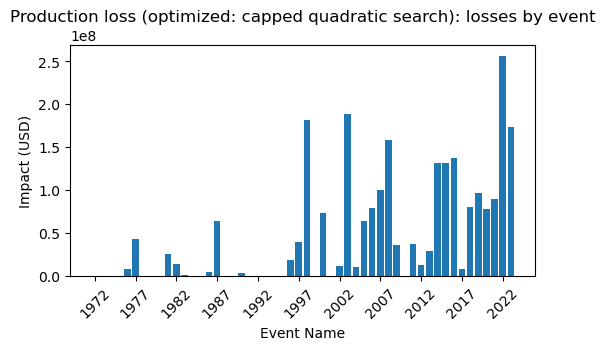

In [24]:
# Recreate the impact calculation with the best parameter values:
impf_best_quadratic = make_quadratic_impact_function(
    original_impf=impf_original,
    impact_start_thresh=best_quadratic_parameters['impact_start_thresh'],
    impact_max_thresh=best_quadratic_parameters['impact_max_thresh'],
    max_impact=best_quadratic_parameters['max_impact']
)

# Update the entity object with the new impact function
entity_optimized = replace_impact_function(entity, impf_best_quadratic)

# Rerun the risk calculation and calculate the cost function as before
imp_best_quadratic, modelled_stats = risk_calc(entity_optimized, haz, return_periods=obs.index)
cost = cost_function(modelled_stats, obs['loss'])

title = f"Production loss (optimized: capped quadratic search): obs vs modelled"
plot_observations_vs_modelled(obs["loss"], modelled_stats, title=title)
title = f"Production loss (optimized: capped quadratic search): exceedance curve"
plot_exceedance(imp_best_quadratic, obs["loss"], title=title)
title = f"Production loss (optimized: capped quadratic search): losses by event"
plot_event_losses(imp_best_quadratic, title=title)

### Discussion: capped quadratic curve

Again, this is a small improvement on the previous functions. It is slightly better able to distinguish the impacts of larger events.

Once again, looking at the range of plausible functions shaded in yellow in the plots, we see that there is still very large uncertainty at higher drought intensities.

There is no way to solve this with such short hazard and observational datasets. More, or longer SPEI simulations would give us more robust hazard return period statistics, but we need observations of more and rarer historical events to improve the calibration.


### Applying expert judgement for a final choice of impact function

Without more observations, we can instead use expert judgement to choose a curve that has both a low cost function and what we think might be a realistic behaviour in very intense droughts.

Instead of choosing the single best function, let's filter to functions that

- have a similar cost (within 25% of the best function)
- have high impacts at very high droughts intensities (`max_impact` at least 0.6)
- have some impact at lower drought intensities (`impact_start_thresh` at least -1)

And take the best function within these parameters:

Number of parameter combinations that meet the filter criteria: 24


,impact_start_thresh,impact_max_thresh,max_impact,cost,colour
5544,-1.0,-2.70,0.70,2.651455e+07,#d8e219
5556,-1.0,-2.65,0.65,2.565737e+07,#dfe318
5557,-1.0,-2.65,0.70,2.709940e+07,#d2e21b
5568,-1.0,-2.60,0.60,2.529479e+07,#e2e418
5569,-1.0,-2.60,0.65,2.533121e+07,#e2e418
5581,-1.0,-2.55,0.60,2.385519e+07,#efe51c
5582,-1.0,-2.55,0.65,2.733155e+07,#d0e11c
5594,-1.0,-2.50,0.60,2.478662e+07,#e7e419
6038,-0.9,-2.80,0.70,2.726722e+07,#d0e11c
6050,-0.9,-2.75,0.65,2.697974e+07,#d2e21b


Best parameters among filtered results:
Impact start threshold: -1.00
Impact max threshold: -2.55
Max impact: 0.60
... with log cost function value: 16.99
2026-06-11 15:44:46,463 - climada.entity.exposures.base - INFO - Exposures matching centroids already found for DR
2026-06-11 15:44:46,466 - climada.engine.impact_calc - INFO - Calculating impact for 14 assets (>0) and 52 events.


/var/folders/cs/l_5t6dbs03l7xx658mdw_t6w0000gn/T/ipykernel_81722/4279189843.py:14: DeprecationWarning: Calculating the frequency curve on user-specified return periods is deprecated. Use ImpactFreqCurve.calc_freq_curve().interpolate() instead.
  rp_impacts = imp.calc_freq_curve(return_per=return_periods).impact


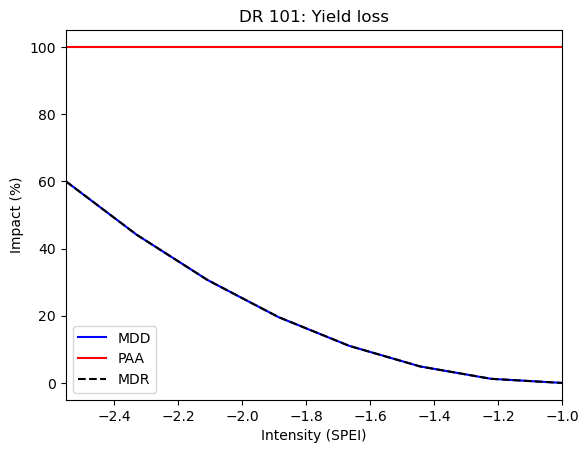

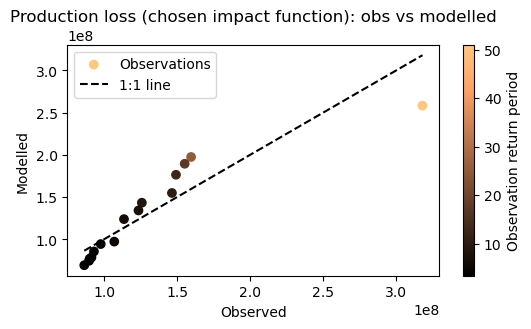

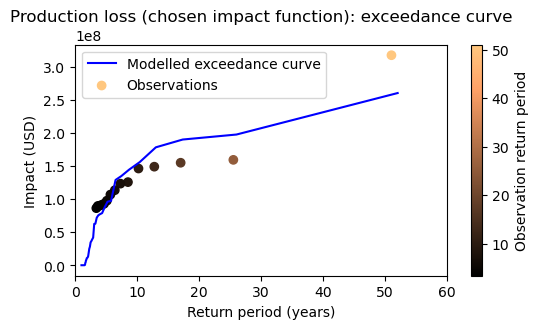

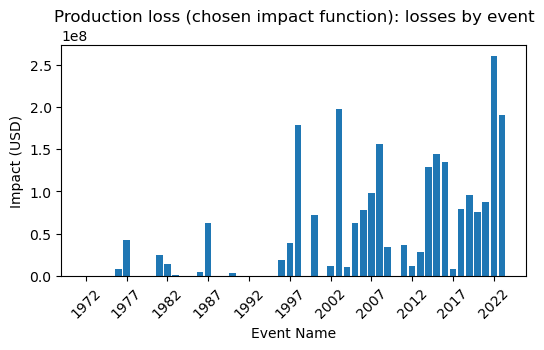

In [25]:
filtered_results = results_quadratic_df[
    (results_quadratic_df['cost'] <= 1.25 * results_quadratic_df['cost'].min()) &
    (results_quadratic_df['max_impact'] >= 0.6) &
    (results_quadratic_df['impact_start_thresh'] >= -1.)
]

print(f"Number of parameter combinations that meet the filter criteria: {len(filtered_results)}")
display(filtered_results)

best_filtered_params = get_best_result(filtered_results)
print(f"Best parameters among filtered results:")
print(f"Impact start threshold: {best_filtered_params['impact_start_thresh']:.2f}")
print(f"Impact max threshold: {best_filtered_params['impact_max_thresh']:.2f}")
print(f"Max impact: {best_filtered_params['max_impact']:.2f}")
print(f"... with log cost function value: {np.log(best_filtered_params['cost']):.2f}")

impf_chosen = make_quadratic_impact_function(
    original_impf=impf_original,
    impact_start_thresh=best_filtered_params['impact_start_thresh'],
    impact_max_thresh=best_filtered_params['impact_max_thresh'],
    max_impact=best_filtered_params['max_impact']
)
impf_chosen.plot()

# Update the entity object with the new impact function
entity_optimized = replace_impact_function(entity, impf_chosen)

# Rerun the risk calculation and calculate the cost function as before
imp_chosen, modelled_stats = risk_calc(entity_optimized, haz, return_periods=obs.index)
cost = cost_function(modelled_stats, obs['loss'])

title = f"Production loss (chosen impact function): obs vs modelled"
plot_observations_vs_modelled(obs["loss"], modelled_stats, title=title)
title = f"Production loss (chosen impact function): exceedance curve"
plot_exceedance(imp_chosen, obs["loss"], title=title)
title = f"Production loss (chosen impact function): losses by event"
plot_event_losses(imp_chosen, title=title)


Optimized impact function cost: 22164317.95
Chosen impact function cost: 23855192.56


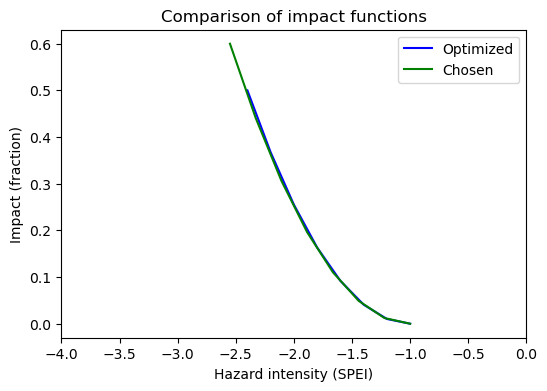

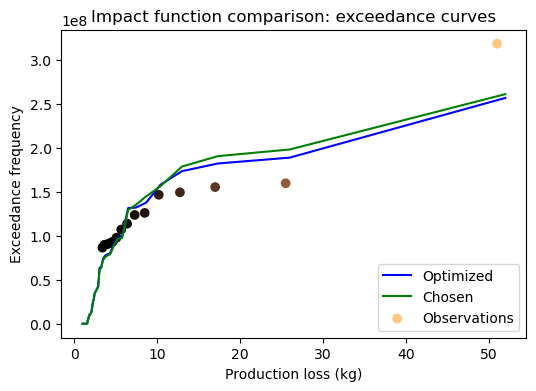

In [26]:
# Compare the best and the chosen impact functions:

print(f"Optimized impact function cost: {best_quadratic_parameters['cost']:.2f}")
print(f"Chosen impact function cost: {best_filtered_params['cost']:.2f}")

# Plot the two impact functions
fig, axis = plt.subplots(figsize=(6, 4))
axis.plot(impf_best_quadratic.intensity, impf_best_quadratic.mdd, color='blue', label='Optimized')
axis.plot(impf_chosen.intensity, impf_chosen.mdd, color='green', label='Chosen')
axis.set_xlabel("Hazard intensity (SPEI)")
axis.set_ylabel("Impact (fraction)")
axis.set_xlim((-4, 0))
axis.legend(loc="upper right")
axis.set_title("Comparison of impact functions")

# Compare the two Exceedance curves
fig, axis = plt.subplots(figsize=(6, 4))
# Plot the optimized curve
exceedance_curve_opt = imp_best_quadratic.calc_freq_curve()
exceedance_curve_chosen = imp_chosen.calc_freq_curve()
exceedance_curve_opt.plot(axis=axis, color="blue", label="Optimized")
exceedance_curve_chosen.plot(axis=axis, color="green", label="Chosen")
axis.scatter(obs.index, obs["loss"], c=obs.index, cmap="copper", label="Observations")
# axis.set_xlim(0, 500)  # Don't zoom in on lower return periods
axis.set_title("Impact function comparison: exceedance curves")
axis.set_xlabel("Production loss (kg)")
axis.set_ylabel("Exceedance frequency")
axis.legend(loc="lower right")
plt.show()
plt.close(axis.figure)

We see that these functions are very similar, the main difference being the value that they are capped at. They create similar exceedance curves and so it is reasonable to use our judgement to allow more intense losses at higher (unseen in our data) drought intensities.

## Write calibrated Entity file

In [27]:
import shutil

# Copy over original file and update with calibrated impact functions
shutil.copy(entity_filepath, calibrated_entity_filepath)

# Open the impact_functions sheet in the Excel file and overwrite with the new impact functions
impf_df = pd.DataFrame({
    "impact_fun_id": impf_chosen.id,
    "intensity_m": impf_chosen.intensity,
    "mdd": impf_chosen.mdd,
    "paa": impf_chosen.paa,
    "peril_id": "DR",
    "name": impf_chosen.name,
    "intensity_unit": "SPEI"
})

print(f"Final impact function. Copy into Excel file to overwrite the original impact functions:")
print(f"File at {calibrated_entity_filepath}")

display(impf_df.style.format({
    "impact_fun_id": "{:d}",
    "intensity_m": "{:.3f}",
    "mdd": "{:.3f}",
    "paa": "{:.3f}"
}))


Final impact function. Copy into Excel file to overwrite the original impact functions:
File at ../data/entity_files_calibrated/El_Salvador_Entity_Drought_Maize_calibrated.xlsx


,impact_fun_id,intensity_m,mdd,paa,peril_id,name,intensity_unit
0,101,-2.550,0.600,1.000,DR,Yield loss,SPEI
1,101,-2.329,0.441,1.000,DR,Yield loss,SPEI
2,101,-2.107,0.306,1.000,DR,Yield loss,SPEI
3,101,-1.886,0.196,1.000,DR,Yield loss,SPEI
4,101,-1.664,0.110,1.000,DR,Yield loss,SPEI
5,101,-1.443,0.049,1.000,DR,Yield loss,SPEI
6,101,-1.221,0.012,1.000,DR,Yield loss,SPEI
7,101,-1.000,0.000,1.000,DR,Yield loss,SPEI
